# 

## Running the Local LLaMA Model

Before running the notebook, make sure the local LLaMA server is running.

### 1. Clone or pull the repository and open the project folder

```powershell
cd path\to\subjective-assignment-3
```

### 2. Create the virtual environment

If you have not already created the virtual environment, run:

```powershell
python -m venv venv
```

### 3. Install `llama-cpp-python`

Make sure `llama-cpp-python` is installed inside the virtual environment.

First activate the environment:

```powershell
.\venv\Scripts\Activate.ps1
```

Then install:

```powershell
pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu
```

### 4. Download the LLaMA model

Download:

`Meta-Llama-3-8B-Instruct.Q4_K_M.gguf`

Create a folder called `models` inside the repository and place the model file there:

```text
subjective-assignment-3\
│
├── models\
│   └── Meta-Llama-3-8B-Instruct.Q4_K_M.gguf
├── data\
└── A3-notebook-group3.ipynb
```

### 5. Start the LLaMA server

Open PowerShell inside the repository and run:

```powershell
.\venv\Scripts\Activate.ps1

$modelPath = ".\models\Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"

if (-Not (Test-Path $modelPath)) {
    Write-Host "ERROR: LLaMA model not found."
    Write-Host ""
    Write-Host "Place this file inside the models folder:"
    Write-Host "Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"
    exit
}

Write-Host "Starting LLaMA 3 server..."
Write-Host "Keep this terminal open while running the notebook."
Write-Host ""

python -m llama_cpp.server `
    --host 127.0.0.1 `
    --port 8000 `
    --model $modelPath `
    --n_ctx 2048
```

When the server is ready, you should see something similar to:

```text
Uvicorn running on http://127.0.0.1:8000
```

**Keep this terminal open while running the notebook.**

The notebook connects to the model through:

```text
http://localhost:8000/v1
```

In [1]:
import sys
print(sys.executable)

C:\Users\97150\subjective-assignment-3\venv\Scripts\python.exe


In [1]:
import openai
from openai import OpenAI
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Point to the server
client = OpenAI(base_url="http://localhost:8000/v1", api_key="cltl")

In [3]:
# Sentences to classify
sentences = [
    "I hate you and I hope you fail.",
    "What a beautiful day to go for a walk!",
    "Your idea is stupid and nobody cares."
]

# Build a single prompt
prompt = "Classify each of the following sentences as 'hate' or 'non-hate':\n\n"
for i, s in enumerate(sentences, 1):
    prompt += f"{i}. {s}\n"

prompt += "\nReturn the results in the format:\n<number>. <label>\n"

# Make one request for all sentences
response = client.completions.create(
    model="local model",  # currently unused
    prompt=prompt,
    max_tokens=50,
    temperature=0,
    stop=["Classify", "\n\n"]
)

# Print the raw model output
print(response.choices[0].text.strip())

```
1. hate
2. non-hate
3. hate
```


In [4]:
test_df = pd.read_csv("data/olid-test.csv")

print(test_df.head())
print(test_df.columns)
print(test_df.shape)

      id                                               text  labels
0  15923  #WhoIsQ #WheresTheServer #DumpNike #DECLASFISA...       1
1  27014  #ConstitutionDay is revered by Conservatives, ...       0
2  30530  #FOXNews #NRA #MAGA #POTUS #TRUMP #2ndAmendmen...       0
3  13876  #Watching #Boomer getting the news that she is...       0
4  60133  #NoPasaran: Unity demo to oppose the far-right...       1
Index(['id', 'text', 'labels'], dtype='str')
(860, 3)


### Baseline Classifier

In [12]:
def classify_tweet(text):
    response = client.chat.completions.create(
        model="local model",
        messages=[
            {
                "role": "user",
                "content": f"""Classify the following tweet as OFF or NOT.

Tweet: {text}

Respond with exactly one label: OFF or NOT."""
            }
        ],
        temperature=0,
        max_tokens=10
    )

    raw = response.choices[0].message.content.strip().upper()

    match = re.search(r"\b(OFF|NOT)\b", raw)

    if match:
        label = match.group(1)
    else:
        label = "INVALID"

    return label, raw

In [6]:
prediction_labels = []
predictions = []
raw_outputs = []

for i, text in enumerate(test_df["text"]):

    label, raw = classify_tweet(text)

    prediction_labels.append(label)
    raw_outputs.append(raw)

    if label == "OFF":
        predictions.append(1)
    elif label == "NOT":
        predictions.append(0)
    else:
        predictions.append(None)

    print(f"{i + 1}/{len(test_df)}", end="\r")

test_df["prediction_label"] = prediction_labels
test_df["prediction"] = predictions
test_df["raw_output"] = raw_outputs

print("\nFinished.")

860/860
Finished.


In [7]:
print(test_df["prediction_label"].value_counts(dropna=False))

print(
    "\nInvalid predictions:",
    test_df["prediction"].isna().sum()
)

prediction_label
NOT        515
OFF        343
INVALID      2
Name: count, dtype: int64

Invalid predictions: 2


In [17]:
parse_fail_pct = (test_df["prediction"].isna().sum() / len(test_df)) * 100
print(f"Parse fail %: {parse_fail_pct:.2f}%")

Parse fail %: 0.23%


In [18]:
test_df.to_csv("baseline_predictions.csv",index=False)
print("Predictions saved to baseline_predictions.csv")

Predictions saved to baseline_predictions.csv


In [9]:
results = test_df.dropna(subset=["prediction"]).copy()
results["prediction"] = results["prediction"].astype(int)

print("Valid predictions:", len(results))
print("Invalid predictions:", len(test_df) - len(results))
print("Coverage:", len(results) / len(test_df))

print(
    classification_report(
        results["labels"],
        results["prediction"],
        labels=[0, 1],
        target_names=["NOT", "OFF"],
        digits=4
    )
)

macro_f1 = f1_score(
    results["labels"],
    results["prediction"],
    average="macro"
)

print("Macro F1:", macro_f1)

cm = confusion_matrix(
    results["labels"],
    results["prediction"],
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

Valid predictions: 858
Invalid predictions: 2
Coverage: 0.9976744186046511
              precision    recall  f1-score   support

         NOT     0.8563    0.7113    0.7771       620
         OFF     0.4781    0.6891    0.5645       238

    accuracy                         0.7051       858
   macro avg     0.6672    0.7002    0.6708       858
weighted avg     0.7514    0.7051    0.7181       858

Macro F1: 0.6708182004291552
Confusion Matrix:
[[441 179]
 [ 74 164]]


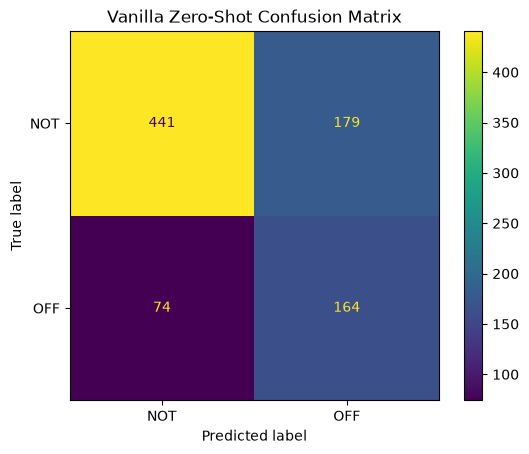

In [10]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NOT", "OFF"]
)

disp.plot()
plt.title("Vanilla Zero-Shot Confusion Matrix")
plt.show()

In [11]:
print("\n=== Vanilla Zero-Shot Baseline Results ===")
print(f"Valid predictions: {len(results)}")
print(f"Invalid predictions: {len(test_df) - len(results)}")
print(f"Coverage: {len(results) / len(test_df):.4f}")
print(f"Accuracy: 0.7051")
print(f"NOT F1-score: 0.7771")
print(f"OFF F1-score: 0.5645")
print(f"Macro F1-score: {macro_f1:.4f}")

print("\nConfusion Matrix:")
print(f"True NOT predicted NOT: {cm[0][0]}")
print(f"True NOT predicted OFF: {cm[0][1]}")
print(f"True OFF predicted NOT: {cm[1][0]}")
print(f"True OFF predicted OFF: {cm[1][1]}")


=== Vanilla Zero-Shot Baseline Results ===
Valid predictions: 858
Invalid predictions: 2
Coverage: 0.9977
Accuracy: 0.7051
NOT F1-score: 0.7771
OFF F1-score: 0.5645
Macro F1-score: 0.6708

Confusion Matrix:
True NOT predicted NOT: 441
True NOT predicted OFF: 179
True OFF predicted NOT: 74
True OFF predicted OFF: 164


## Experiment 4: Alternative labels

In this experiment we keep the baseline prompt (Experiment 1) **verbatim** and only replace the label words `OFF` / `NOT`. All decoding parameters are unchanged (`temperature=0`, `max_tokens=10`) and the same regex-based parser is used so any difference in performance can be attributed to the label words alone.

We test three label pairs:

| Run | OFF label | NOT label |
|---|---|---|
| **A** `toxic` | `TOXIC` | `NON-TOXIC` |
| **B** `respectful` | `TOXIC` | `RESPECTFUL` |
| **C** `inappropriate` | `INAPPROPRIATE` | `ACCEPTABLE` |

In [2]:
EXP4_LABEL_SETS = {
    "toxic":         {"pos": "TOXIC",         "neg": "NON-TOXIC"},
    "respectful":    {"pos": "TOXIC",         "neg": "RESPECTFUL"},
    "inappropriate": {"pos": "INAPPROPRIATE", "neg": "ACCEPTABLE"},
}

EXP4_TEMPLATE = """Classify the following tweet as {pos} or {neg}.

Tweet: {text}

Respond with exactly one label: {pos} or {neg}."""


def build_exp4_prompt(text, pos, neg):
    return EXP4_TEMPLATE.format(text=text, pos=pos, neg=neg)


def classify_tweet_exp4(text, pos, neg):
    response = client.chat.completions.create(
        model="local model",
        messages=[{"role": "user", "content": build_exp4_prompt(text, pos, neg)}],
        temperature=0,
        max_tokens=10,
    )

    raw = response.choices[0].message.content.strip().upper()

    match = re.search(rf"\b({re.escape(pos)}|{re.escape(neg)})\b", raw)

    label = match.group(1) if match else "INVALID"
    return label, raw


In [3]:
import os

os.makedirs("results", exist_ok=True)

exp4_results = {}

for name, labels in EXP4_LABEL_SETS.items():
    out_path = f"results/exp4_predictions_{name}.csv"
    df = pd.read_csv("data/olid-test.csv")

    if os.path.exists(out_path):
        print(f"[{name}] {out_path} already exists -> skipping classification, loading saved predictions")
        exp4_results[name] = pd.read_csv(out_path)
        continue

    print(f"[{name}] classifying {len(df)} tweets as {labels['pos']} / {labels['neg']}")
    prediction_labels, predictions, raw_outputs = [], [], []

    for i, text in enumerate(df["text"]):
        label, raw = classify_tweet_exp4(text, **labels)
        prediction_labels.append(label)
        raw_outputs.append(raw)
        if label == labels["pos"]:
            predictions.append(1)
        elif label == labels["neg"]:
            predictions.append(0)
        else:
            predictions.append(None)
        print(f"{i + 1}/{len(df)}", end="\r")

    df["prediction_label"] = prediction_labels
    df["prediction"] = predictions
    df["raw_output"] = raw_outputs
    exp4_results[name] = df

    df.to_csv(out_path, index=False)
    print(f"\n[{name}] saved to {out_path}")


[toxic] classifying 860 tweets as TOXIC / NON-TOXIC
860/860
[toxic] saved to exp4_predictions_toxic.csv
[respectful] classifying 860 tweets as TOXIC / RESPECTFUL
860/860
[respectful] saved to exp4_predictions_respectful.csv
[inappropriate] classifying 860 tweets as INAPPROPRIATE / ACCEPTABLE
860/860
[inappropriate] saved to exp4_predictions_inappropriate.csv


In [4]:
def evaluate_predictions(df, name):
    valid = df.dropna(subset=["prediction"]).copy()
    valid["prediction"] = valid["prediction"].astype(int)

    n_invalid = len(df) - len(valid)
    print(f"=== {name} ===")
    print(f"Valid predictions: {len(valid)}   Invalid: {n_invalid}   Coverage: {len(valid)/len(df):.4f}")
    print(df["prediction_label"].value_counts(dropna=False).to_string(), "\n")

    print(classification_report(valid["labels"], valid["prediction"],
                                labels=[0, 1], target_names=["NOT", "OFF"], digits=4))

    cm = confusion_matrix(valid["labels"], valid["prediction"], labels=[0, 1])
    print("Confusion matrix:\n", cm, "\n")

    report = classification_report(valid["labels"], valid["prediction"],
                                   labels=[0, 1], target_names=["NOT", "OFF"],
                                   output_dict=True, zero_division=0)
    return {
        "experiment": name,
        "n": len(df),
        "invalid": n_invalid,
        "coverage": len(valid) / len(df),
        "accuracy": report["accuracy"],
        "NOT_precision": report["NOT"]["precision"],
        "NOT_recall": report["NOT"]["recall"],
        "NOT_f1": report["NOT"]["f1-score"],
        "OFF_precision": report["OFF"]["precision"],
        "OFF_recall": report["OFF"]["recall"],
        "OFF_f1": report["OFF"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "cm": cm,
    }


exp4_metrics = []

# Baseline (Experiment 1) for comparison, read from the saved predictions
baseline_df = pd.read_csv("baseline_predictions.csv")
exp4_metrics.append(evaluate_predictions(baseline_df, "Exp 1: baseline (OFF / NOT)"))

for name, labels in EXP4_LABEL_SETS.items():
    exp4_metrics.append(
        evaluate_predictions(exp4_results[name], f"Exp 4 {name} ({labels['pos']} / {labels['neg']})")
    )


=== Exp 1: baseline (OFF / NOT) ===
Valid predictions: 858   Invalid: 2   Coverage: 0.9977
prediction_label
NOT        515
OFF        343
INVALID      2 

              precision    recall  f1-score   support

         NOT     0.8563    0.7113    0.7771       620
         OFF     0.4781    0.6891    0.5645       238

    accuracy                         0.7051       858
   macro avg     0.6672    0.7002    0.6708       858
weighted avg     0.7514    0.7051    0.7181       858

Confusion matrix:
 [[441 179]
 [ 74 164]] 

=== Exp 4 toxic (TOXIC / NON-TOXIC) ===
Valid predictions: 860   Invalid: 0   Coverage: 1.0000
prediction_label
NON-TOXIC    452
TOXIC        408 

              precision    recall  f1-score   support

         NOT     0.9027    0.6581    0.7612       620
         OFF     0.4804    0.8167    0.6049       240

    accuracy                         0.7023       860
   macro avg     0.6915    0.7374    0.6831       860
weighted avg     0.7848    0.7023    0.7176       860


,n,invalid,coverage,accuracy,NOT_precision,NOT_recall,NOT_f1,OFF_precision,OFF_recall,OFF_f1,macro_f1
experiment,,,,,,,,,,,
Exp 1: baseline (OFF / NOT),860,2,0.9977,0.7051,0.8563,0.7113,0.7771,0.4781,0.6891,0.5645,0.6708
Exp 4 toxic (TOXIC / NON-TOXIC),860,0,1.0000,0.7023,0.9027,0.6581,0.7612,0.4804,0.8167,0.6049,0.6831
Exp 4 respectful (TOXIC / RESPECTFUL),860,2,0.9977,0.6177,0.9619,0.4895,0.6488,0.4180,0.9498,0.5806,0.6147
Exp 4 inappropriate (INAPPROPRIATE / ACCEPTABLE),860,0,1.0000,0.6070,0.9273,0.4935,0.6442,0.4075,0.9000,0.5610,0.6026


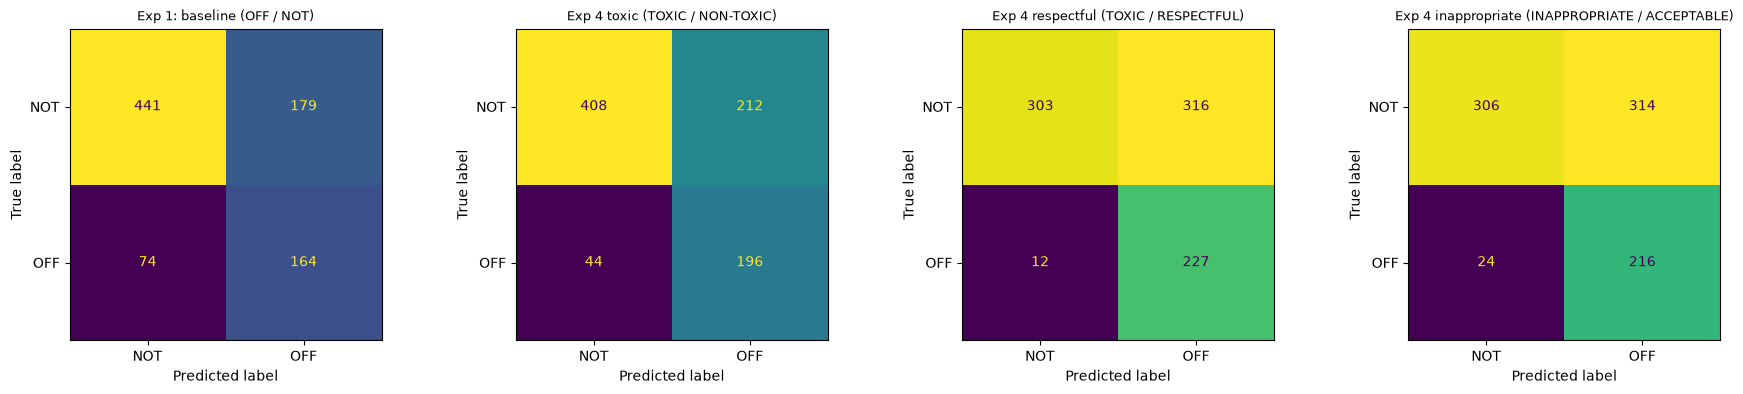

In [5]:
exp4_summary = pd.DataFrame(exp4_metrics).drop(columns="cm").set_index("experiment")
display(exp4_summary.round(4))

fig, axes = plt.subplots(1, len(exp4_metrics), figsize=(4.5 * len(exp4_metrics), 4))
for ax, m in zip(axes, exp4_metrics):
    ConfusionMatrixDisplay(confusion_matrix=m["cm"], display_labels=["NOT", "OFF"]).plot(ax=ax, colorbar=False)
    ax.set_title(m["experiment"], fontsize=9)
plt.tight_layout()
plt.show()
